# Notebook 3.0: Baseline Model Training on Google Colab

**Project:** Empirical Research and Integration of Dual-Branch GCN-CNN Architecture for FER

This notebook trains the **MobileNetV2 Baseline Model** on the image branch of our refined dataset. It implements:
- Google Drive integration for model checkpoints and reporting.
- Local Colab disk unzipping for maximum I/O speed.
- Comprehensive logging of all parameters, training metrics (saved as a CSV log), loss/accuracy curves, classification reports, and normalized confusion matrices.

---

## Environment Preparation
Install and verify all required libraries in the Google Colab environment. (Colab usually has TensorFlow, OpenCV, Scikit-Learn, Seaborn, and Matplotlib pre-installed, but running this ensures all requirements are met).

In [2]:
# Install core libraries required for the project
# Note: TensorFlow, OpenCV, Scikit-Learn, Seaborn, and Matplotlib are generally pre-installed on Google Colab.
# You can run this command to update or verify them:
!pip install -q tensorflow opencv-python scikit-learn seaborn matplotlib

# Alternatively, if uploading requirements.txt on Drive,
# then can mounting to Drive (in the next step) and run the following:
# !pip install -r path-to-file-requirements.txt

## Step 1: Mount Google Drive
Connect to your Google Drive to load the dataset and save the outputs permanently.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Set up High-Speed Local Storage & Unzip Dataset
Reading thousands of individual files from Google Drive is slow because of network latency. We copy the compressed zip archive from Drive to the local Colab disk (`/content/`) and unzip it here. This speeds up training significantly.

In [3]:
# 1. Create a local data directory
!mkdir -p /content/data

In [4]:
# 2. Copy the zip dataset from Drive (adjust path if different)
!cp /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/data.zip /content/final_dataset.zip

In [5]:
# 3. Unzip the dataset into Colab local directory
!unzip -q /content/final_dataset.zip -d /content/

In [6]:
# 4. Verify the directories are present
!ls -lh /content/data/final

total 12K
drwxr-xr-x 4 root root 4.0K Jun  8 16:09 test
drwxr-xr-x 4 root root 4.0K Jun  8 16:09 train
drwxr-xr-x 4 root root 4.0K Jun  8 16:09 val


## Step 3: Set up Custom Project Modules
Copy the `src` folder from Drive and add the root path to `sys.path` so we can import our custom data loaders.

In [7]:
# 1. Copy src directory from Drive to Colab local directory
!cp -r /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/src/ /content/src

In [9]:
# 2. Append path to python import path list
import sys
if '/content' not in sys.path:
    sys.path.append('/content')

print("Python path updated successfully:")
for path in sys.path:
    print(path)

Python path updated successfully:
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/usr/lib/python3/dist-packages
/usr/local/lib/python3.12/dist-packages/IPython/extensions
/root/.ipython


## Step 4: Import Libraries and Verify Hardware GPU

### GPU Diagnostic and Fix
If your GPU is not detected even on a T4 runtime, we need to check if the system sees the hardware and ensure TensorFlow is correctly installed.

In [10]:
# Step A: Check if the OS sees the NVIDIA GPU
!nvidia-smi

Sat Jun 13 06:11:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Note:** After running the reinstall cell above, MUST go to **Runtime -> Restart session** for the changes to take effect before running the 'Verify Hardware GPU' cell again.

### Final Hardware Verification
Run this cell after having performed the **Runtime -> Change runtime type** toggle described above.

In [11]:
import tensorflow as tf
import os
import subprocess

print("--- Backend Hardware Check ---")
# Check for NVIDIA drivers
has_nvidia = os.path.exists('/dev/nvidia0')
print(f"NVIDIA Device Node Found: {has_nvidia}")

try:
    # Try to get hardware info
    res = subprocess.check_output(['nvidia-smi', '-L']).decode('utf-8')
    print(f"Hardware Identity: {res}")
except:
    print("RESULT: OS does not see any GPU hardware. Please use 'Disconnect and delete runtime' and then ensure T4 is selected.")

print("\n--- TensorFlow Status ---")
devices = tf.config.list_physical_devices('GPU')
if devices:
    print(f"SUCCESS: TensorFlow is linked to GPU: {devices}")
else:
    print("FAILURE: TensorFlow is restricted to CPU.")

--- Backend Hardware Check ---
NVIDIA Device Node Found: True
Hardware Identity: GPU 0: Tesla T4 (UUID: GPU-f1099a09-a935-3c26-a2fa-90866af7ad12)


--- TensorFlow Status ---
SUCCESS: TensorFlow is linked to GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
import tensorflow as tf
# Re-enable and configure GPU for Colab
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Memory growth prevents TF from grabbing all VRAM at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"SUCCESS: GPU Detected and configured: {gpus[0]}")
    except RuntimeError as e:
        print(e)
else:
    print("CRITICAL: GPU NOT FOUND. Please 'Disconnect and delete runtime' then set Runtime to T4 GPU.")

SUCCESS: GPU Detected and configured: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [15]:
import os
import logging
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## Step 5: Configure Output Paths on Google Drive
Define and create the folders on Google Drive where model weights, logs, plots, and classification reports will be written.

In [17]:
DRIVE_PROJECT = Path('/content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/')
DRIVE_REPORTS = DRIVE_PROJECT / 'reports'
DRIVE_MODELS = DRIVE_PROJECT / 'models'

# Ensure directories exist
DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)

print(f"Reports folder on Drive: {DRIVE_REPORTS}")
print(f"Models folder on Drive: {DRIVE_MODELS}")

Reports folder on Drive: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/reports
Models folder on Drive: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models


## Step 6: Load Datasets via Custom DataLoader
Using our `src.data.data_loader` module to load data in `((image, graph), label)` format. Since the MobileNetV2 baseline is an image-only model, we map the batches to yield only `(image, label)`. The loader also replicates the single grayscale channel to 3 channels on-the-fly (`to_rgb=True`) to be compatible with pretrained ImageNet weights.

In [27]:
from src.data.data_loader import get_data_loader, LABELS

BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-4


print("Loading datasets...")
print("Loading Train, Val, and Test loaders...")

train_ds = get_data_loader('train', batch_size=BATCH_SIZE, to_rgb=True, augment=True, shuffle=True)
val_ds = get_data_loader('val', batch_size=BATCH_SIZE, to_rgb=True, augment=False, shuffle=False)
test_ds = get_data_loader('test', batch_size=BATCH_SIZE, to_rgb=True, augment=False, shuffle=False)

# Map to extract image branch only
train_ds_img = train_ds.map(lambda inputs, label: (inputs[0], label))
val_ds_img = val_ds.map(lambda inputs, label: (inputs[0], label))
test_ds_img = test_ds.map(lambda inputs, label: (inputs[0], label))

print("DataLoader initialization finished.")

Loading datasets...
Loading Train, Val, and Test loaders...
DataLoader initialization finished.


## Step 7: Build MobileNetV2 Baseline Model
Initialize MobileNetV2 with pretrained ImageNet weights. Freeze the backbone and append new classification layers on top.

In [28]:
def build_mobilenet_baseline():
    print("Initializing MobileNetV2 backbone...")
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze backbone

    inputs = tf.keras.Input(shape=(224, 224, 3), name="image_input")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(len(LABELS), activation='softmax', name="output_layer")(x)

    model = tf.keras.Model(inputs, outputs, name="MobileNetV2_Baseline")

    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_mobilenet_baseline()
model.summary()


Initializing MobileNetV2 backbone...


Model: "MobileNetV2_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 8: Set up Callbacks for Full Logging & Monitoring
Configure callbacks to log training epochs into a CSV file, save weights of the best validation accuracy epoch, and automatically regulate the learning rate.

In [29]:
import datetime
import os
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
try:
    from tqdm.keras import TqdmCallback
except ImportError:
    !pip install tqdm
    from tqdm.keras import TqdmCallback

# --- New: Timestamped folder setup ---
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
LOG_DIR = DRIVE_REPORTS / f"epoch-training-details-{timestamp}"
LOG_DIR.mkdir(parents=True, exist_ok=True)

# --- New: Custom Step-by-Step Logger ---
class StepLoggerCallback(Callback):
    def __init__(self, log_dir):
        super().__init__()
        self.log_dir = log_dir

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_dir = self.log_dir / f"epoch_{epoch+1}"
        self.epoch_dir.mkdir(parents=True, exist_ok=True)

    def on_train_batch_end(self, batch, logs=None):
        # Save logs for every single step/batch
        step_file = self.epoch_dir / f"step_{batch+1}.txt"
        with open(step_file, 'w') as f:
            f.write(f"Step: {batch+1}\n")
            for key, value in logs.items():
                f.write(f"{key}: {value}\n")

# 1. Summary CSV Logger (Final results per epoch)
csv_logger = CSVLogger(str(DRIVE_REPORTS / 'baseline_training_summary.csv'), separator=',', append=False)

# 2. Step Logger
step_logger = StepLoggerCallback(LOG_DIR)

# 3. Best Model Checkpoint
checkpoint = ModelCheckpoint(
    filepath=str(DRIVE_MODELS / 'baseline_mobilenetv2.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 4. Standard Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
tqdm_cb = TqdmCallback(verbose=1)

callbacks = [csv_logger, step_logger, checkpoint, early_stopping, lr_scheduler, tqdm_cb]
print(f"Callbacks configured. Step logs will be saved to: {LOG_DIR}")

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Callbacks configured. Step logs will be saved to: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/reports/epoch-training-details-20260613-063437


## Step 9: Train the Model
Fit the model using the training and validation loaders.

In [31]:
import tensorflow as tf

print("Calculating dataset size for the progress bar (this may take a moment)... ")
# If cardinality is unknown, we manually count the steps once
train_batches = tf.data.experimental.cardinality(train_ds_img).numpy()

if train_batches < 0:
    # Manually iterate to find the length
    train_batches = 0
    for _ in train_ds_img:
        train_batches += 1

print(f"Starting baseline training. Total batches: {train_batches}")

history = model.fit(
    train_ds_img,
    epochs=EPOCHS,
    validation_data=val_ds_img,
    callbacks=callbacks,
    verbose=0,
    steps_per_epoch=train_batches
)
print("Training complete.")

Calculating dataset size for the progress bar (this may take a moment)... 
Starting baseline training. Total batches: 282

Epoch 1: val_accuracy improved from None to 0.51098, saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: finished saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras

Epoch 2: val_accuracy did not improve from 0.51098

Epoch 3: val_accuracy improved from 0.51098 to 0.53802, saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras

Epoch 3: finished saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras

Epoch 4: val_accuracy did not improve from 0.53802

Epoch 5: val_accuracy improved from 0.53802 to 0.55625, saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras

Epoch 5: finished saving model to /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/models/baseline_mobilenetv2.keras

Epoch 6: val_accuracy did not improve from 0.55625

Epoch 7: val_accuracy did not improve from 0.55625

Epoch 8: val_accurac

## Step 10: Plot and Save Training Curves
Generate training and validation accuracy/loss plots and save them directly to Google Drive.

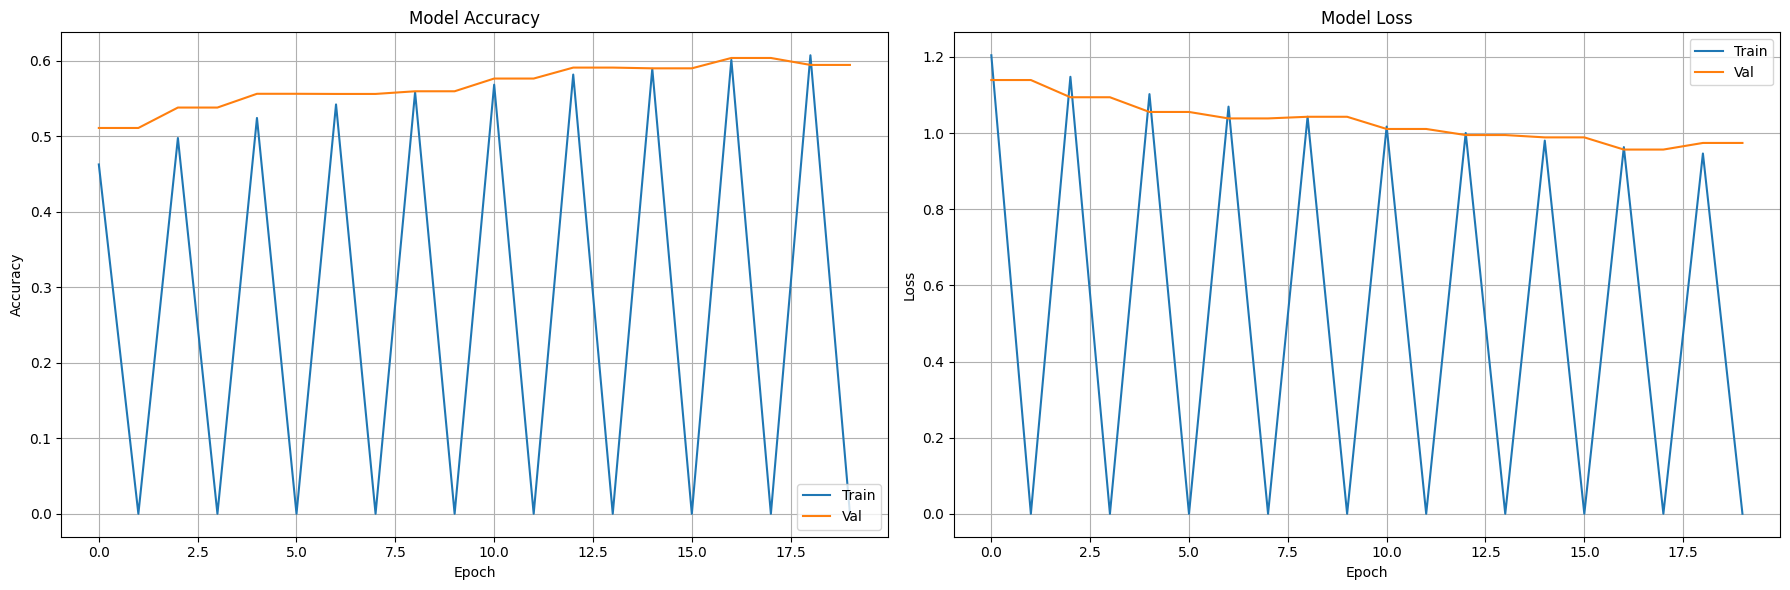

Training curves saved to: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/reports/baseline_training_curves.png


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
curves_path = DRIVE_REPORTS / "baseline_training_curves.png"
plt.savefig(str(curves_path), dpi=150)
plt.show()
print(f"Training curves saved to: {curves_path}")

## Step 11: Run Inference and Generate Classification Report
Evaluate performance on the test dataset. Print metrics and export them to a text file in Drive.

In [33]:
print("Evaluating model on test dataset...")
y_true_list = []
y_pred_list = []

for img_batch, label_batch in test_ds_img:
    preds = model.predict(img_batch, verbose=0)
    y_true_list.extend(np.argmax(label_batch.numpy(), axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# 1. Classification report
report = classification_report(y_true, y_pred, target_names=LABELS)
print("\nClassification Report:\n" + report)

# 2. Save text report to Drive
report_path = DRIVE_REPORTS / "baseline_classification_report.txt"
with open(report_path, "w") as f:
    f.write(report)
print(f"Classification report text file saved to: {report_path}")

Evaluating model on test dataset...

Classification Report:
              precision    recall  f1-score   support

       anger       0.44      0.46      0.45       711
   happiness       0.77      0.71      0.74      2005
     neutral       0.58      0.63      0.60      1347
     sadness       0.47      0.47      0.47      1039

    accuracy                           0.61      5102
   macro avg       0.56      0.57      0.57      5102
weighted avg       0.61      0.61      0.61      5102

Classification report text file saved to: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/reports/baseline_classification_report.txt


## Step 12: Plot and Save Normalized Confusion Matrix
Plot confusion matrix showing predicted versus actual counts, normalize across row values, and save to Drive.

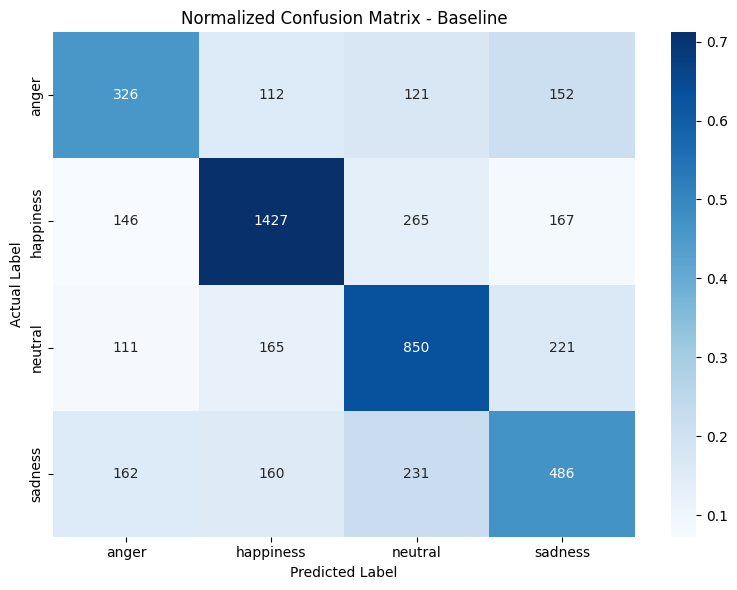

Confusion matrix saved to: /content/drive/MyDrive/mentor-fptaiez/sp-fptu/sem-09/dpl302m-fer-dual/reports/baseline_confusion_matrix.png
Google Colab training process complete!


In [34]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=cm,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=True
)
plt.title('Normalized Confusion Matrix - Baseline')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

matrix_path = DRIVE_REPORTS / "baseline_confusion_matrix.png"
plt.savefig(str(matrix_path), dpi=150)
plt.show()
print(f"Confusion matrix saved to: {matrix_path}")
print("Google Colab training process complete!")